# Walmart Sales Forecasting
End-to-end pipeline: EDA → Feature Engineering → Prophet → XGBoost → Final Validation

In [2]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import os

# Download dataset
path = kagglehub.dataset_download("aslanahmedov/walmart-sales-forecast")

features_df = pd.read_csv(os.path.join(path, "features.csv"))
stores_df   = pd.read_csv(os.path.join(path, "stores.csv"))
train_df    = pd.read_csv(os.path.join(path, "train.csv"))
test_df     = pd.read_csv(os.path.join(path, "test.csv"))

print("features_df:", features_df.shape)
print("stores_df  :", stores_df.shape)
print("train_df   :", train_df.shape)
print("test_df    :", test_df.shape)

features_df: (8190, 12)
stores_df  : (45, 3)
train_df   : (421570, 5)
test_df    : (115064, 4)


## Data Preprocessing

In [4]:
# Drop MarkDown columns (>60% missing, low predictive value)
features_df = features_df.drop(
    columns=["MarkDown1", "MarkDown2", "MarkDown3", "MarkDown4", "MarkDown5"]
)

# Parse dates
train_df["Date"]    = pd.to_datetime(train_df["Date"])
features_df["Date"] = pd.to_datetime(features_df["Date"])

# Merge all data sources
df = train_df.merge(features_df, on=["Store", "Date", "IsHoliday"], how="left")
df = df.merge(stores_df, on="Store", how="left")
df = df.sort_values("Date").reset_index(drop=True)

print("Merged shape:", df.shape)
df.head()

Merged shape: (421570, 11)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,211.096358,8.106,A,151315
1,29,5,2010-02-05,15552.08,False,24.36,2.788,131.527903,10.064,B,93638
2,29,6,2010-02-05,3200.22,False,24.36,2.788,131.527903,10.064,B,93638
3,29,7,2010-02-05,10820.05,False,24.36,2.788,131.527903,10.064,B,93638
4,29,8,2010-02-05,20055.64,False,24.36,2.788,131.527903,10.064,B,93638


## Exploratory Data Analysis

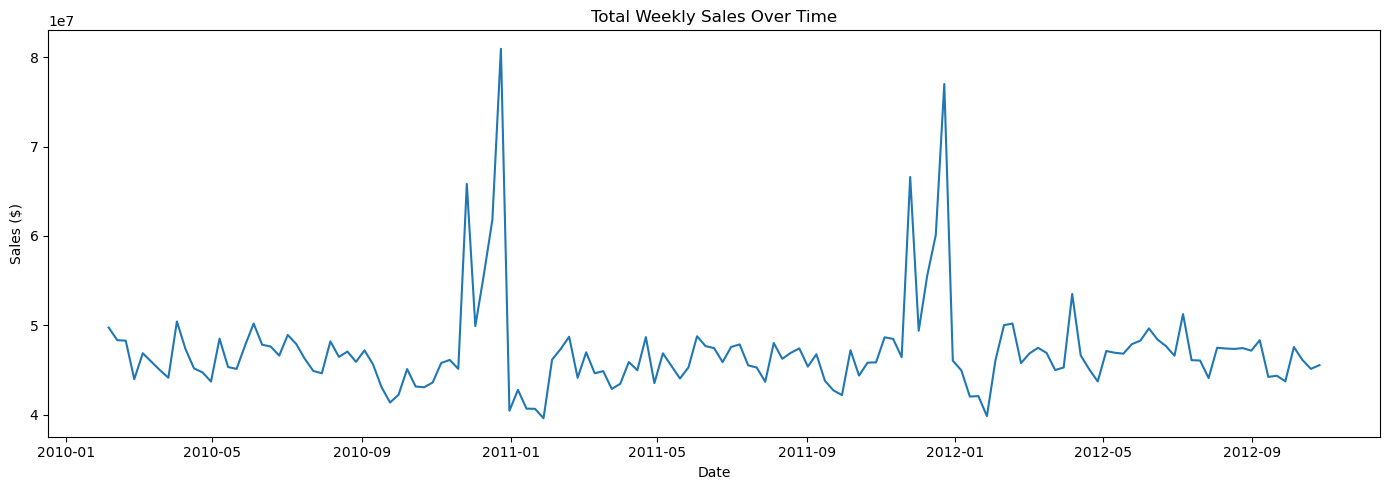

In [6]:
weekly_sales = df.groupby("Date")["Weekly_Sales"].sum()

plt.figure(figsize=(14, 5))
plt.plot(weekly_sales)
plt.title("Total Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales ($)")
plt.tight_layout()
plt.show()

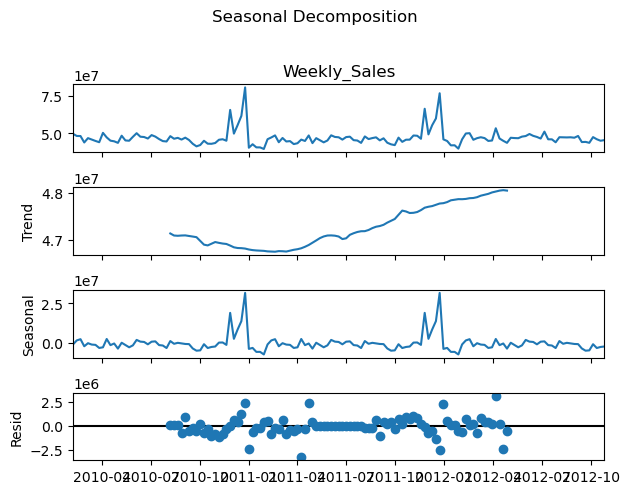

In [7]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(weekly_sales, model="additive", period=52)
decomposition.plot()
plt.suptitle("Seasonal Decomposition", y=1.02)
plt.tight_layout()
plt.show()

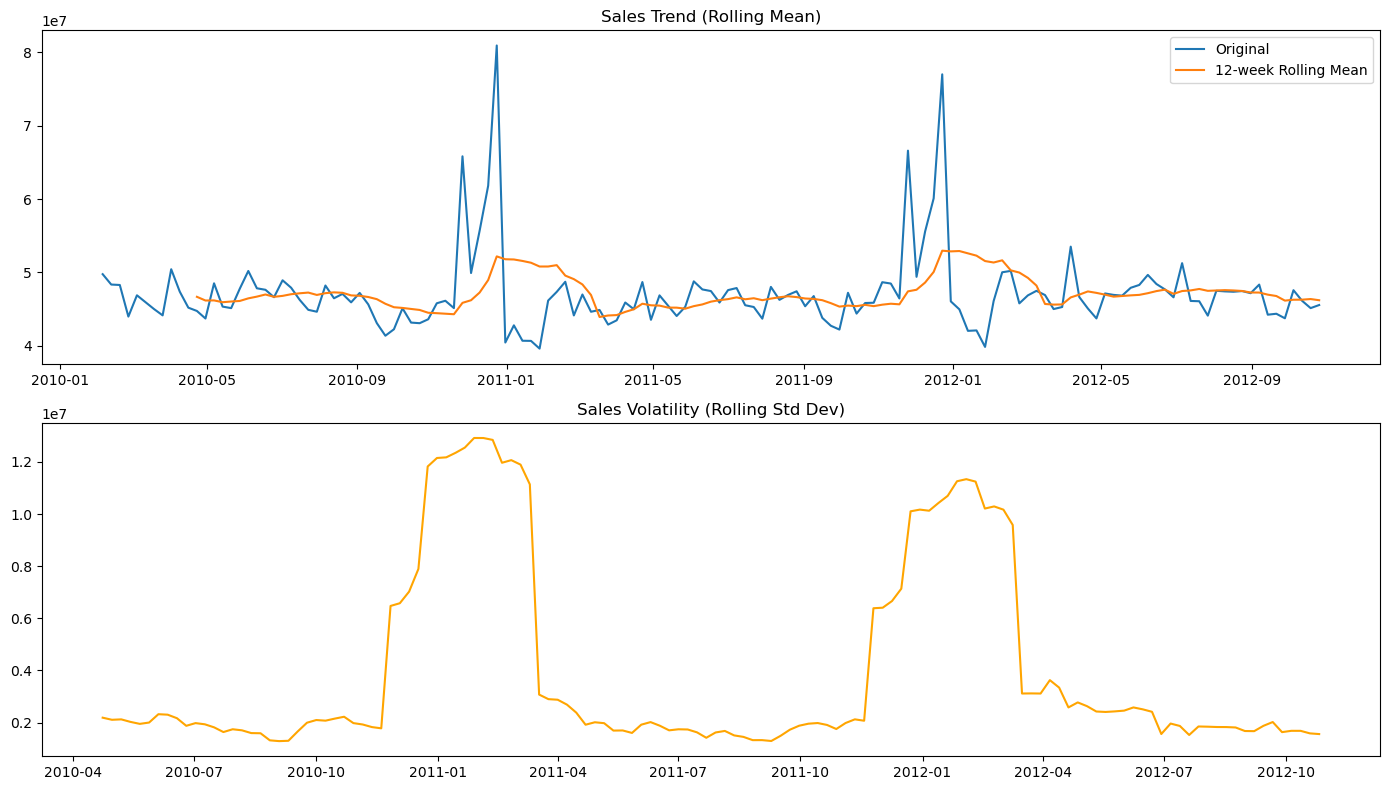

In [8]:
weekly_sales_df = weekly_sales.to_frame()
weekly_sales_df["Rolling_Mean"] = weekly_sales_df["Weekly_Sales"].rolling(window=12).mean()
weekly_sales_df["Rolling_STD"]  = weekly_sales_df["Weekly_Sales"].rolling(window=12).std()

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(weekly_sales_df["Weekly_Sales"], label="Original")
axes[0].plot(weekly_sales_df["Rolling_Mean"], label="12-week Rolling Mean")
axes[0].set_title("Sales Trend (Rolling Mean)")
axes[0].legend()

axes[1].plot(weekly_sales_df["Rolling_STD"], color="orange")
axes[1].set_title("Sales Volatility (Rolling Std Dev)")

plt.tight_layout()
plt.show()

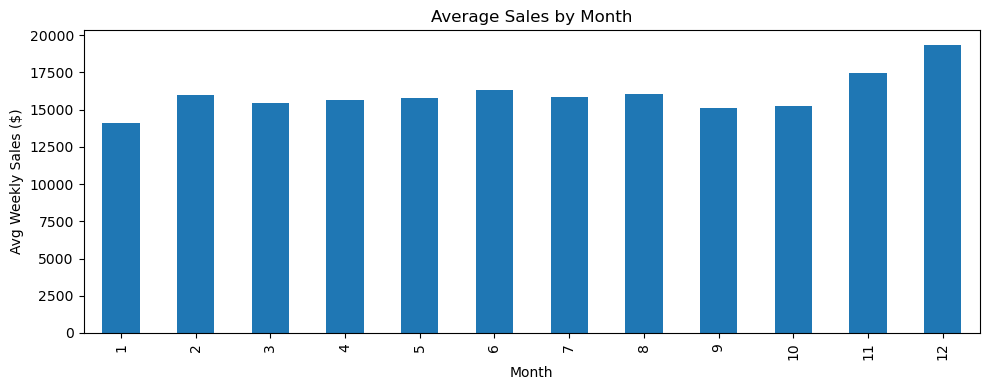

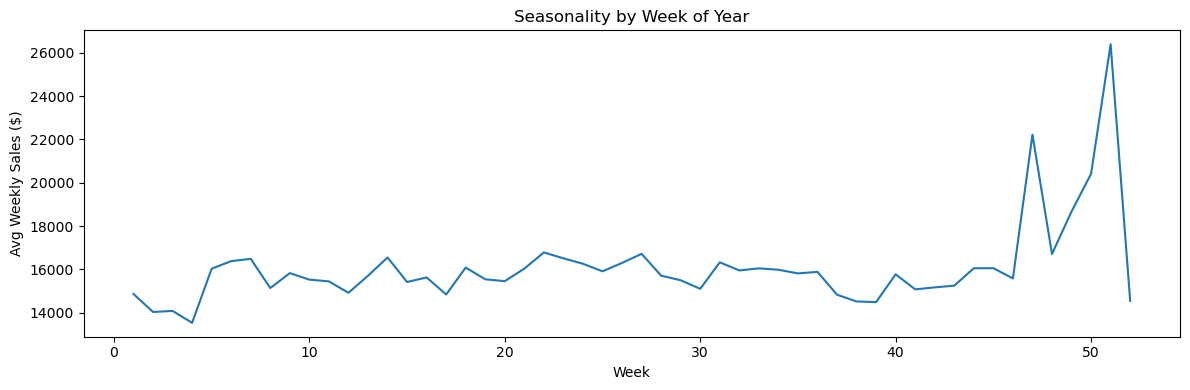

In [9]:
# Average sales by month
monthly_pattern = df.groupby(df["Date"].dt.month)["Weekly_Sales"].mean()
monthly_pattern.plot(kind="bar", figsize=(10, 4))
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Avg Weekly Sales ($)")
plt.tight_layout()
plt.show()

# Average sales by ISO week
df["Week"] = df["Date"].dt.strftime('%U').astype(int)
weekly_pattern = df.groupby("Week")["Weekly_Sales"].mean()
weekly_pattern.plot(figsize=(12, 4))
plt.title("Seasonality by Week of Year")
plt.xlabel("Week")
plt.ylabel("Avg Weekly Sales ($)")
plt.tight_layout()
plt.show()

In [10]:
# Holiday impact
holiday_sales = df.groupby("IsHoliday")["Weekly_Sales"].mean()
print("Average weekly sales by holiday flag:")
print(holiday_sales)

cv = weekly_sales.std() / weekly_sales.mean()
print(f"\nCoefficient of Variation: {cv:.4f}")

Average weekly sales by holiday flag:
IsHoliday
False    15901.445069
True     17035.823187
Name: Weekly_Sales, dtype: float64

Coefficient of Variation: 0.1156


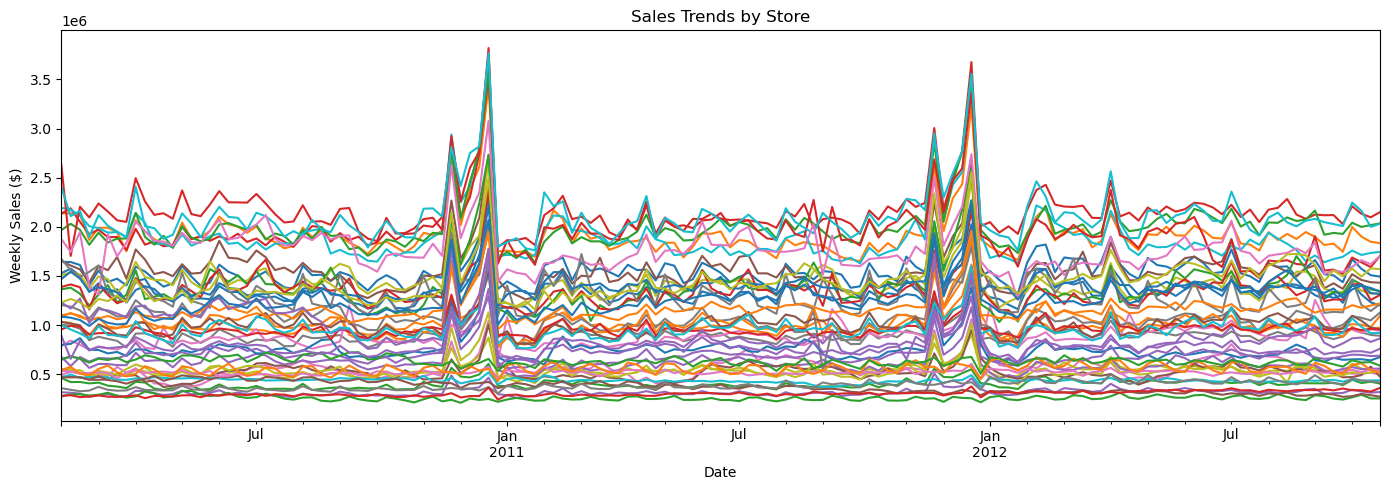

In [11]:
# Per-store sales trends
store_trend = df.groupby(["Date", "Store"])["Weekly_Sales"].sum().unstack()
store_trend.plot(figsize=(14, 5), legend=False)
plt.title("Sales Trends by Store")
plt.xlabel("Date")
plt.ylabel("Weekly Sales ($)")
plt.tight_layout()
plt.show()

## Feature Engineering

In [13]:
df_model = df.copy()

# Drop the Week column we created during EDA — will recreate cleanly
if "Week" in df_model.columns:
    df_model = df_model.drop(columns=["Week"])

# Time-based features
df_model["Year"]      = df_model["Date"].dt.year
df_model["Month"]     = df_model["Date"].dt.month
df_model["Week"]      = df_model["Date"].dt.strftime('%U').astype(int)
df_model["Quarter"]   = df_model["Date"].dt.quarter
df_model["DayOfYear"] = df_model["Date"].dt.dayofyear

# Holiday flags
df_model["IsBlackFriday"]  = ((df_model["Month"] == 11) & (df_model["Week"] >= 47)).astype(int)
df_model["IsChristmas"]    = ((df_model["Month"] == 12) & (df_model["Week"] >= 51)).astype(int)
df_model["IsThanksgiving"] = ((df_model["Month"] == 11) & (df_model["Week"] >= 46) & (df_model["Week"] < 47)).astype(int)

# Store type encoding
df_model["Type_A"] = (df_model["Type"] == "A").astype(int)
df_model["Type_B"] = (df_model["Type"] == "B").astype(int)
df_model["Type_C"] = (df_model["Type"] == "C").astype(int)

# Lag features (requires sorting by store/dept/date)
df_model = df_model.sort_values(["Store", "Dept", "Date"]).reset_index(drop=True)
for lag in [1, 4, 8, 52]:
    df_model[f"Sales_Lag_{lag}"] = df_model.groupby(["Store", "Dept"])["Weekly_Sales"].shift(lag)

# Rolling statistics
for window in [4, 8, 12]:
    df_model[f"Sales_MA_{window}"]  = df_model.groupby(["Store", "Dept"])["Weekly_Sales"].transform(
        lambda x: x.rolling(window=window, min_periods=1).mean()
    )
    df_model[f"Sales_STD_{window}"] = df_model.groupby(["Store", "Dept"])["Weekly_Sales"].transform(
        lambda x: x.rolling(window=window, min_periods=1).std()
    )

print(f"Features before: {len(df.columns)}")
print(f"Features after : {len(df_model.columns)}")

Features before: 12
Features after : 32


## Data Preparation & Train/Val Split

In [15]:
# Drop rows with NaN caused by lag features (first ~52 weeks per Store/Dept)
df_model_clean = df_model.dropna()
print(f"Rows before cleaning : {len(df_model):,}")
print(f"Rows after  cleaning : {len(df_model_clean):,}")
print(f"Rows removed (NaN lags): {len(df_model) - len(df_model_clean):,}")

available_features = [
    "Store", "Dept", "Size",
    "Week", "Month", "Quarter", "DayOfYear",
    "IsHoliday", "IsBlackFriday", "IsChristmas", "IsThanksgiving",
    "Type_A", "Type_B", "Type_C",
    "Sales_Lag_1", "Sales_Lag_4", "Sales_Lag_8", "Sales_Lag_52",
    "Sales_MA_4",  "Sales_MA_8",  "Sales_MA_12",
    "Sales_STD_4", "Sales_STD_8", "Sales_STD_12",
]

# Time-based split (no data leakage)
split_date = "2012-08-01"
train = df_model_clean[df_model_clean["Date"] <  split_date]
val   = df_model_clean[df_model_clean["Date"] >= split_date]

X_train, y_train = train[available_features], train["Weekly_Sales"]
X_val,   y_val   = val[available_features],   val["Weekly_Sales"]

print(f"\nTraining  : {len(train):,} samples  ({train['Date'].min().date()} → {train['Date'].max().date()})")
print(f"Validation: {len(val):,}  samples  ({val['Date'].min().date()}   → {val['Date'].max().date()})")
print(f"Features  : {len(available_features)}")

Rows before cleaning : 421,570
Rows after  cleaning : 261,083
Rows removed (NaN lags): 160,487

Training  : 223,218 samples  (2011-02-04 → 2012-07-27)
Validation: 37,865  samples  (2012-08-03   → 2012-10-26)
Features  : 24


## Prophet Model

In [17]:
!pip install prophet -q

In [18]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Aggregate to total weekly sales for Prophet
df_prophet = df.groupby("Date").agg({"Weekly_Sales": "sum"}).reset_index()
df_prophet.columns = ["ds", "y"]

split_date_dt = pd.to_datetime("2012-08-01")
prophet_train = df_prophet[df_prophet["ds"] <  split_date_dt].reset_index(drop=True)
prophet_val   = df_prophet[df_prophet["ds"] >= split_date_dt].reset_index(drop=True)

# Define holiday calendar
holidays = pd.concat([
    pd.DataFrame({"holiday": "black_friday",
                  "ds": pd.to_datetime(["2010-11-26", "2011-11-25", "2012-11-23"]),
                  "lower_window": -1, "upper_window": 1}),
    pd.DataFrame({"holiday": "christmas",
                  "ds": pd.to_datetime(["2010-12-24", "2011-12-24", "2012-12-24"]),
                  "lower_window": -1, "upper_window": 1}),
], ignore_index=True)

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    holidays=holidays,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.05
)
prophet_model.fit(prophet_train)

# Predictions
prophet_train_pred = prophet_model.predict(prophet_train[["ds"]])["yhat"].values
prophet_val_pred   = prophet_model.predict(prophet_val[["ds"]])["yhat"].values

prophet_train_rmse = np.sqrt(mean_squared_error(prophet_train["y"], prophet_train_pred))
prophet_val_rmse   = np.sqrt(mean_squared_error(prophet_val["y"],   prophet_val_pred))
prophet_val_mae    = mean_absolute_error(prophet_val["y"], prophet_val_pred)
prophet_val_r2     = r2_score(prophet_val["y"], prophet_val_pred)

print(f"Prophet — Train RMSE: ${prophet_train_rmse:,.2f}")
print(f"Prophet — Val   RMSE: ${prophet_val_rmse:,.2f}")
print(f"Prophet — Val   MAE : ${prophet_val_mae:,.2f}")
print(f"Prophet — Val   R²  : {prophet_val_r2:.4f}")

15:42:07 - cmdstanpy - INFO - Chain [1] start processing
15:42:07 - cmdstanpy - INFO - Chain [1] done processing


Prophet — Train RMSE: $1,756,975.99
Prophet — Val   RMSE: $1,413,464.58
Prophet — Val   MAE : $1,207,509.84
Prophet — Val   R²  : 0.0780


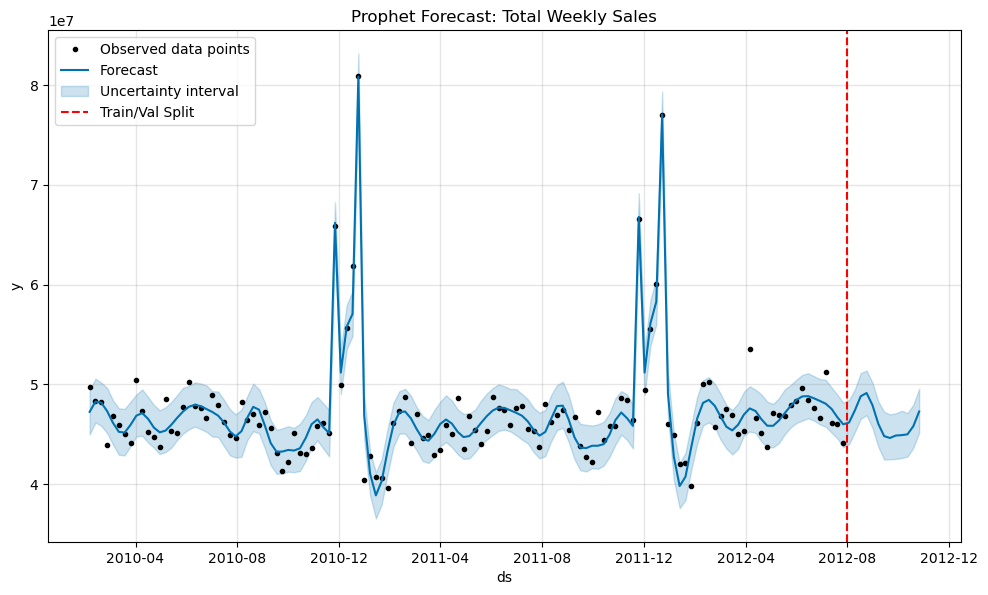

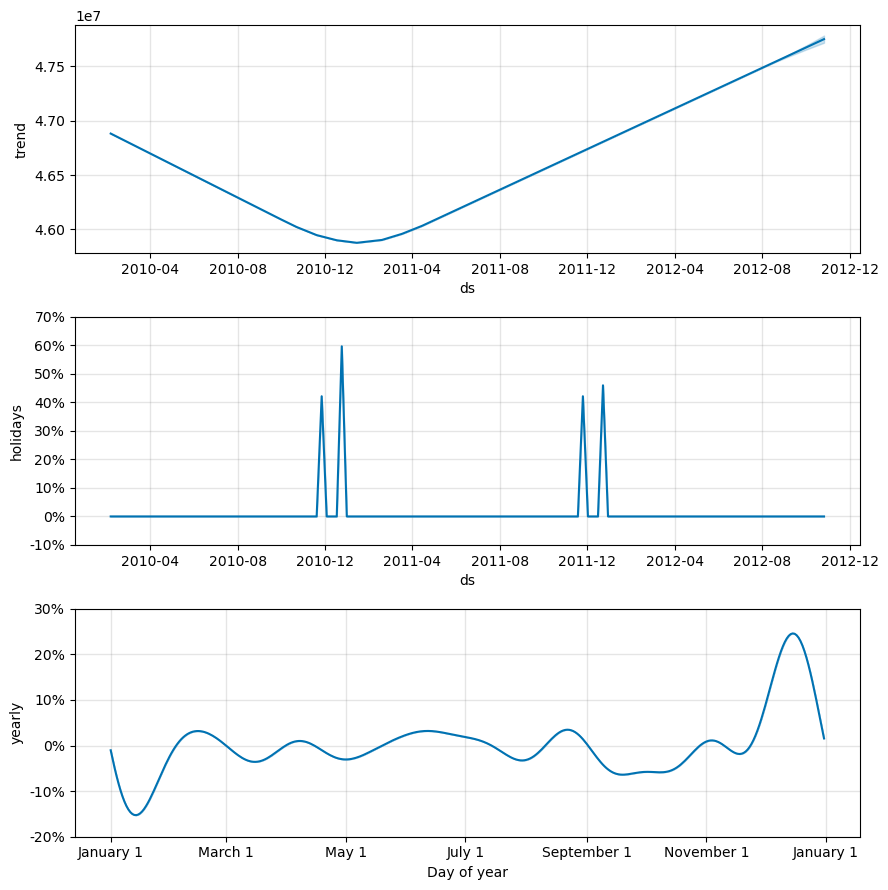

In [19]:
# Prophet forecast plot
prophet_forecast = prophet_model.predict(
    pd.concat([prophet_train[["ds"]], prophet_val[["ds"]]], ignore_index=True)
)
fig1 = prophet_model.plot(prophet_forecast)
plt.title("Prophet Forecast: Total Weekly Sales")
plt.axvline(x=split_date_dt, color="red", linestyle="--", label="Train/Val Split")
plt.legend()
plt.show()

# Decomposed components
fig2 = prophet_model.plot_components(prophet_forecast)
plt.show()

## XGBoost Model

In [21]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    early_stopping_rounds=50
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=50
)

xgb_train_pred = xgb_model.predict(X_train)
xgb_val_pred   = xgb_model.predict(X_val)

xgb_train_rmse = np.sqrt(mean_squared_error(y_train, xgb_train_pred))
xgb_val_rmse   = np.sqrt(mean_squared_error(y_val,   xgb_val_pred))
xgb_val_mae    = mean_absolute_error(y_val, xgb_val_pred)
xgb_val_r2     = r2_score(y_val, xgb_val_pred)

print(f"XGBoost — Train RMSE: ${xgb_train_rmse:,.2f}")
print(f"XGBoost — Val   RMSE: ${xgb_val_rmse:,.2f}")
print(f"XGBoost — Val   MAE : ${xgb_val_mae:,.2f}")
print(f"XGBoost — Val   R²  : {xgb_val_r2:.4f}")

[0]	validation_0-rmse:21786.98966	validation_1-rmse:20962.58178
[50]	validation_0-rmse:3357.53299	validation_1-rmse:2803.58167
[100]	validation_0-rmse:2538.39828	validation_1-rmse:2264.21956
[150]	validation_0-rmse:2340.48821	validation_1-rmse:2235.84621
[200]	validation_0-rmse:2190.05147	validation_1-rmse:2219.73042
[250]	validation_0-rmse:2093.35488	validation_1-rmse:2207.03423
[300]	validation_0-rmse:2008.26037	validation_1-rmse:2193.28875
[350]	validation_0-rmse:1932.84401	validation_1-rmse:2184.57953
[400]	validation_0-rmse:1867.53360	validation_1-rmse:2177.46063
[450]	validation_0-rmse:1815.01393	validation_1-rmse:2166.50930
[499]	validation_0-rmse:1773.73086	validation_1-rmse:2157.11483
XGBoost — Train RMSE: $1,773.73
XGBoost — Val   RMSE: $2,157.11
XGBoost — Val   MAE : $1,010.88
XGBoost — Val   R²  : 0.9904


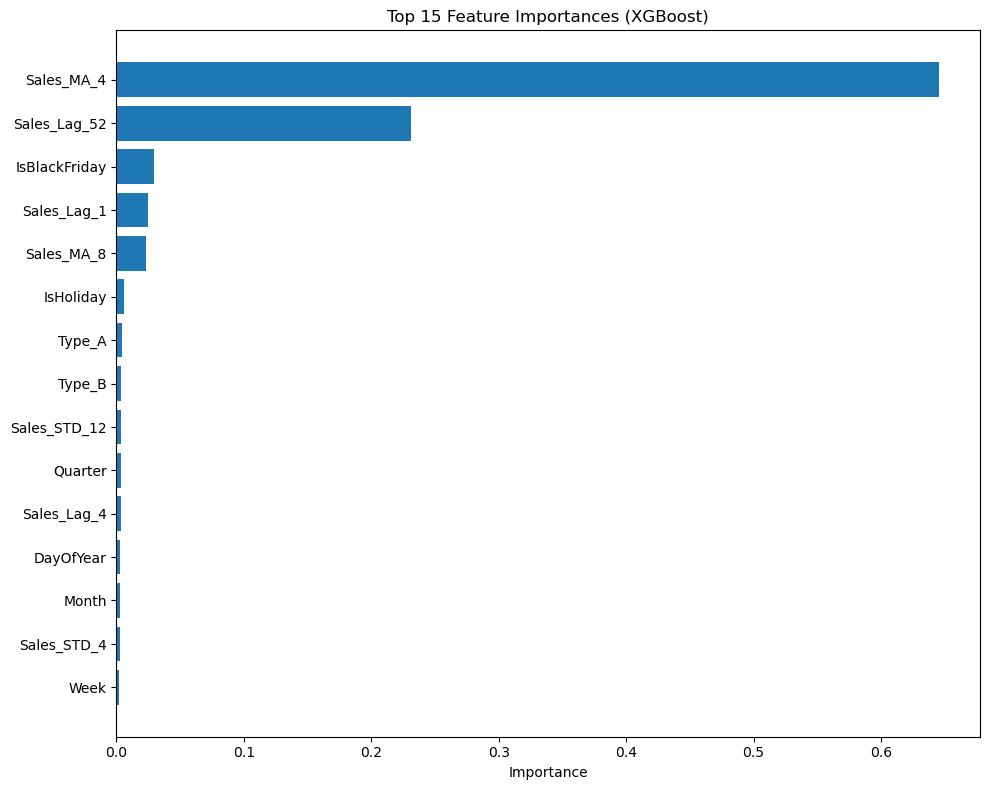

In [22]:
# Feature importance
feature_importance = pd.DataFrame({
    "feature":    available_features,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 8))
top15 = feature_importance.head(15)
plt.barh(top15["feature"], top15["importance"])
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Residual Analysis (XGBoost)

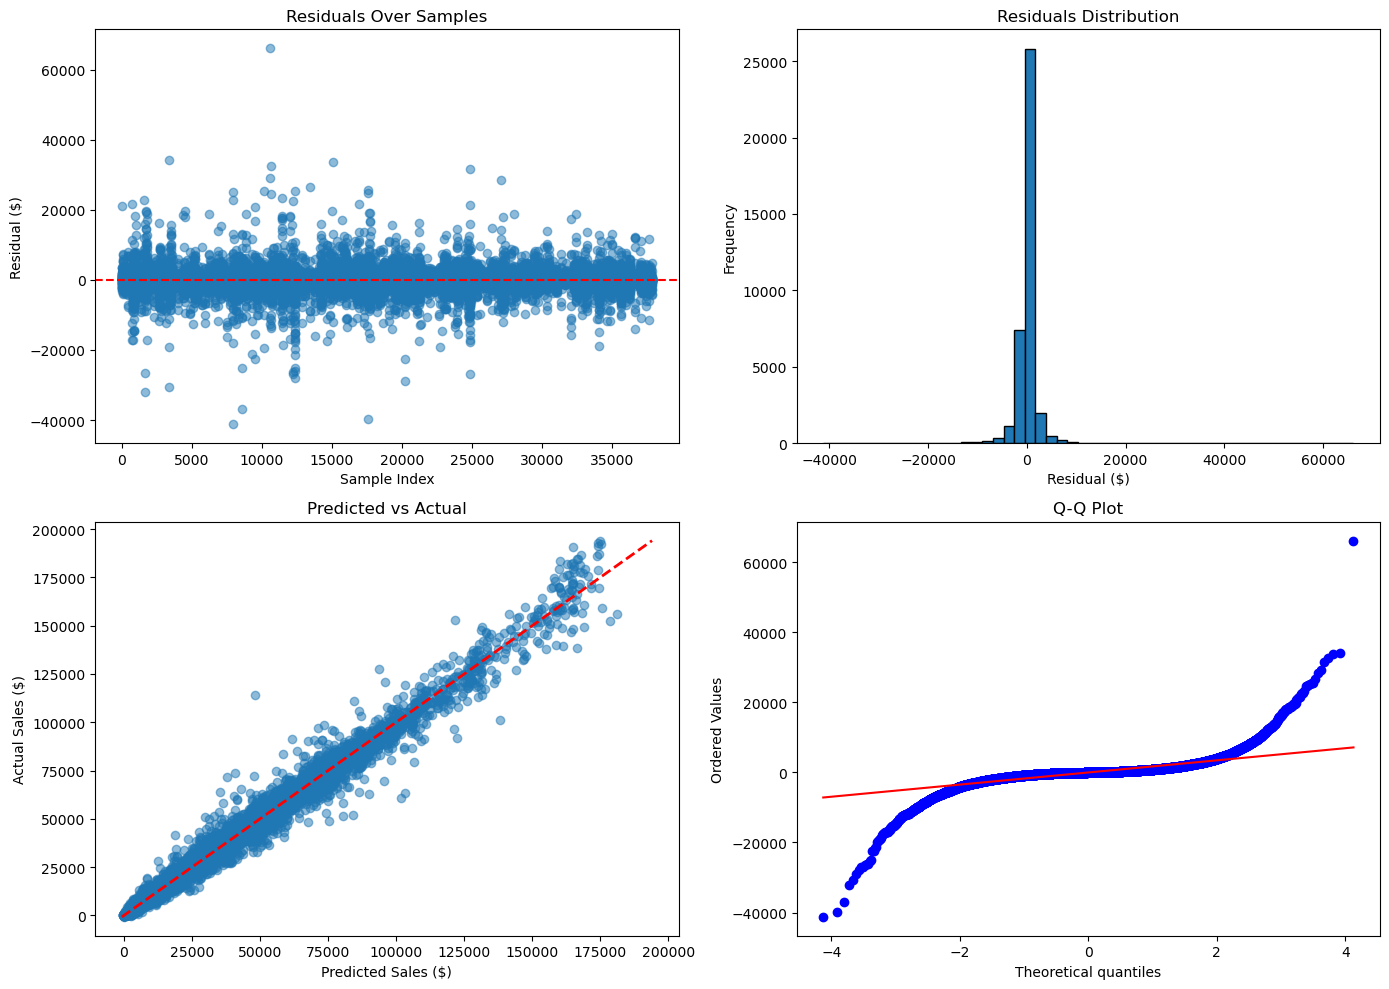

In [24]:
from scipy import stats

xgb_residuals = y_val.values - xgb_val_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(range(len(xgb_residuals)), xgb_residuals, alpha=0.5)
axes[0, 0].axhline(y=0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals Over Samples")
axes[0, 0].set_xlabel("Sample Index")
axes[0, 0].set_ylabel("Residual ($)")

axes[0, 1].hist(xgb_residuals, bins=50, edgecolor="black")
axes[0, 1].set_title("Residuals Distribution")
axes[0, 1].set_xlabel("Residual ($)")
axes[0, 1].set_ylabel("Frequency")

axes[1, 0].scatter(xgb_val_pred, y_val.values, alpha=0.5)
axes[1, 0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "r--", lw=2)
axes[1, 0].set_title("Predicted vs Actual")
axes[1, 0].set_xlabel("Predicted Sales ($)")
axes[1, 0].set_ylabel("Actual Sales ($)")

stats.probplot(xgb_residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot")

plt.tight_layout()
plt.show()

## Model Comparison

  Model   Train_RMSE     Val_RMSE      Val_MAE   Val_R2
Prophet 1.756976e+06 1.413465e+06 1.207510e+06 0.078005
XGBoost 1.773731e+03 2.157115e+03 1.010877e+03 0.990421

Best model: XGBoost


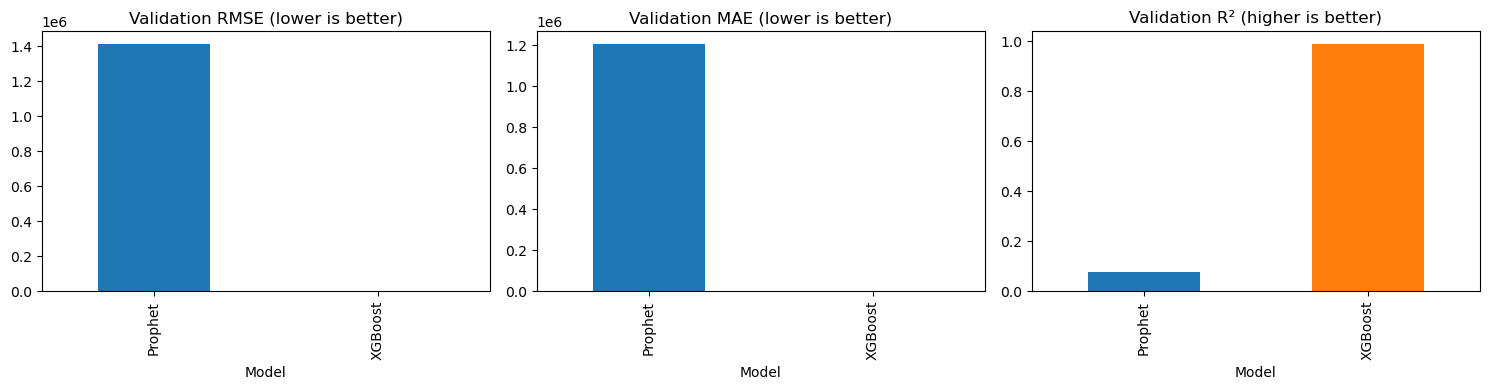

In [26]:
comparison = pd.DataFrame({
    "Model":      ["Prophet", "XGBoost"],
    "Train_RMSE": [prophet_train_rmse, xgb_train_rmse],
    "Val_RMSE":   [prophet_val_rmse,   xgb_val_rmse],
    "Val_MAE":    [prophet_val_mae,    xgb_val_mae],
    "Val_R2":     [prophet_val_r2,     xgb_val_r2],
})
print(comparison.to_string(index=False))

best_model = "Prophet" if prophet_val_rmse < xgb_val_rmse else "XGBoost"
print(f"\nBest model: {best_model}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
comparison.plot(x="Model", y="Val_RMSE", kind="bar", ax=axes[0], legend=False, color=["#1f77b4", "#ff7f0e"])
axes[0].set_title("Validation RMSE (lower is better)")
comparison.plot(x="Model", y="Val_MAE",  kind="bar", ax=axes[1], legend=False, color=["#1f77b4", "#ff7f0e"])
axes[1].set_title("Validation MAE (lower is better)")
comparison.plot(x="Model", y="Val_R2",   kind="bar", ax=axes[2], legend=False, color=["#1f77b4", "#ff7f0e"])
axes[2].set_title("Validation R² (higher is better)")
plt.tight_layout()
plt.show()

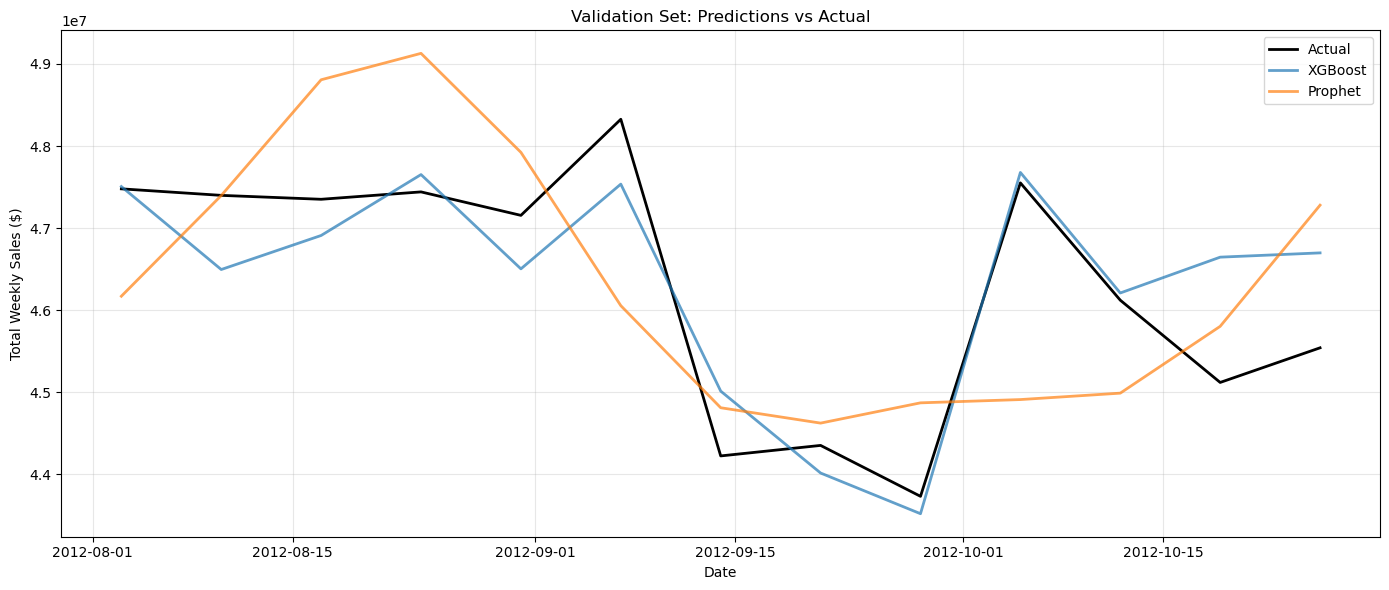

In [27]:
# Aggregate XGBoost predictions by date and overlay with Prophet
val_results = val[["Date", "Weekly_Sales"]].copy()
val_results["XGBoost_Pred"] = xgb_val_pred
val_agg = val_results.groupby("Date").agg({"Weekly_Sales": "sum", "XGBoost_Pred": "sum"}).reset_index()

prophet_val_df = prophet_val.copy()
prophet_val_df["Prophet_Pred"] = prophet_val_pred
val_agg = val_agg.merge(prophet_val_df[["ds", "Prophet_Pred"]], left_on="Date", right_on="ds", how="left")

plt.figure(figsize=(14, 6))
plt.plot(val_agg["Date"], val_agg["Weekly_Sales"],   label="Actual",  linewidth=2, color="black")
plt.plot(val_agg["Date"], val_agg["XGBoost_Pred"],  label="XGBoost", linewidth=2, alpha=0.7)
plt.plot(val_agg["Date"], val_agg["Prophet_Pred"],  label="Prophet", linewidth=2, alpha=0.7)
plt.title("Validation Set: Predictions vs Actual")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales ($)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Final Validation — Robust Train / Val / Test Split

In [29]:
# Three-way chronological split
train_end = "2012-06-01"
val_end   = "2012-08-01"

train_data = df_model_clean[df_model_clean["Date"] <  train_end].copy()
val_data   = df_model_clean[(df_model_clean["Date"] >= train_end) & (df_model_clean["Date"] < val_end)].copy()
test_data  = df_model_clean[df_model_clean["Date"] >= val_end].copy()

print(f"Training  : {len(train_data):,} samples ({train_data['Date'].min().date()} → {train_data['Date'].max().date()})")
print(f"Validation: {len(val_data):,}  samples ({val_data['Date'].min().date()}   → {val_data['Date'].max().date()})")
print(f"Test      : {len(test_data):,}  samples ({test_data['Date'].min().date()}   → {test_data['Date'].max().date()})")

X_train_final, y_train_final = train_data[available_features], train_data["Weekly_Sales"]
X_val_final,   y_val_final   = val_data[available_features],   val_data["Weekly_Sales"]
X_test_final,  y_test_final  = test_data[available_features],  test_data["Weekly_Sales"]

Training  : 197,201 samples (2011-02-04 → 2012-05-25)
Validation: 26,017  samples (2012-06-01   → 2012-07-27)
Test      : 37,865  samples (2012-08-03   → 2012-10-26)


In [30]:
# Hyperparameter grid search on val set
param_grid = {
    "learning_rate": [0.03, 0.05, 0.07],
    "max_depth":     [5, 6, 7],
}

results = []
for lr in param_grid["learning_rate"]:
    for depth in param_grid["max_depth"]:
        m = XGBRegressor(
            n_estimators=500, learning_rate=lr, max_depth=depth,
            subsample=0.8, colsample_bytree=0.8,
            random_state=42, n_jobs=-1, early_stopping_rounds=50
        )
        m.fit(X_train_final, y_train_final, eval_set=[(X_val_final, y_val_final)], verbose=0)
        vp = m.predict(X_val_final)
        results.append({
            "learning_rate": lr, "max_depth": depth,
            "val_rmse": np.sqrt(mean_squared_error(y_val_final, vp)),
            "val_r2":   r2_score(y_val_final, vp),
        })
        print(f"  lr={lr}, depth={depth} → RMSE ${results[-1]['val_rmse']:,.2f}  R² {results[-1]['val_r2']:.4f}")

results_df = pd.DataFrame(results)
best_params = results_df.loc[results_df["val_rmse"].idxmin()]
print(f"\nBest: lr={best_params['learning_rate']}, max_depth={int(best_params['max_depth'])}")

  lr=0.03, depth=5 → RMSE $2,404.97  R² 0.9883
  lr=0.03, depth=6 → RMSE $2,341.71  R² 0.9889
  lr=0.03, depth=7 → RMSE $2,263.61  R² 0.9896
  lr=0.05, depth=5 → RMSE $2,347.06  R² 0.9889
  lr=0.05, depth=6 → RMSE $2,273.32  R² 0.9896
  lr=0.05, depth=7 → RMSE $2,233.07  R² 0.9899
  lr=0.07, depth=5 → RMSE $2,303.02  R² 0.9893
  lr=0.07, depth=6 → RMSE $2,248.01  R² 0.9898
  lr=0.07, depth=7 → RMSE $2,206.84  R² 0.9902

Best: lr=0.07, max_depth=7


In [31]:
# Train final model with best hyperparameters
final_model = XGBRegressor(
    n_estimators=500,
    learning_rate=best_params["learning_rate"],
    max_depth=int(best_params["max_depth"]),
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, early_stopping_rounds=50
)

final_model.fit(
    X_train_final, y_train_final,
    eval_set=[(X_train_final, y_train_final), (X_val_final, y_val_final)],
    verbose=50
)
print("Training complete.")

[0]	validation_0-rmse:21421.09078	validation_1-rmse:20707.05484
[50]	validation_0-rmse:2570.41809	validation_1-rmse:2436.49936
[100]	validation_0-rmse:2112.61739	validation_1-rmse:2338.06591
[150]	validation_0-rmse:1899.25336	validation_1-rmse:2302.30748
[200]	validation_0-rmse:1765.84653	validation_1-rmse:2280.91079
[250]	validation_0-rmse:1664.69538	validation_1-rmse:2262.62965
[300]	validation_0-rmse:1581.50946	validation_1-rmse:2240.30735
[350]	validation_0-rmse:1513.87891	validation_1-rmse:2231.78260
[400]	validation_0-rmse:1450.93900	validation_1-rmse:2219.04182
[450]	validation_0-rmse:1398.35912	validation_1-rmse:2212.56064
[499]	validation_0-rmse:1353.32495	validation_1-rmse:2208.19986
Training complete.


In [32]:
def calculate_metrics(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return {"Set": set_name, "RMSE": rmse, "MAE": mae, "R2": r2, "MAPE": mape}

train_pred_final = final_model.predict(X_train_final)
val_pred_final   = final_model.predict(X_val_final)
test_pred_final  = final_model.predict(X_test_final)

train_metrics = calculate_metrics(y_train_final, train_pred_final, "Training")
val_metrics   = calculate_metrics(y_val_final,   val_pred_final,   "Validation")
test_metrics  = calculate_metrics(y_test_final,  test_pred_final,  "Test")

metrics_comparison = pd.DataFrame([train_metrics, val_metrics, test_metrics])
print(metrics_comparison.to_string(index=False))

r2_drop        = train_metrics["R2"] - test_metrics["R2"]
rmse_gap_pct   = (test_metrics["RMSE"] - train_metrics["RMSE"]) / train_metrics["RMSE"] * 100
print(f"\nR² drop (train→test) : {r2_drop:.4f}")
print(f"RMSE increase        : {rmse_gap_pct:.1f}%")

       Set        RMSE         MAE       R2  MAPE
  Training 1355.752373  798.480275 0.996520   inf
Validation 2206.837555 1006.616437 0.990158   inf
      Test 2137.014916  971.641160 0.990599   inf

R² drop (train→test) : 0.0059
RMSE increase        : 57.6%


## Final Model Visualizations

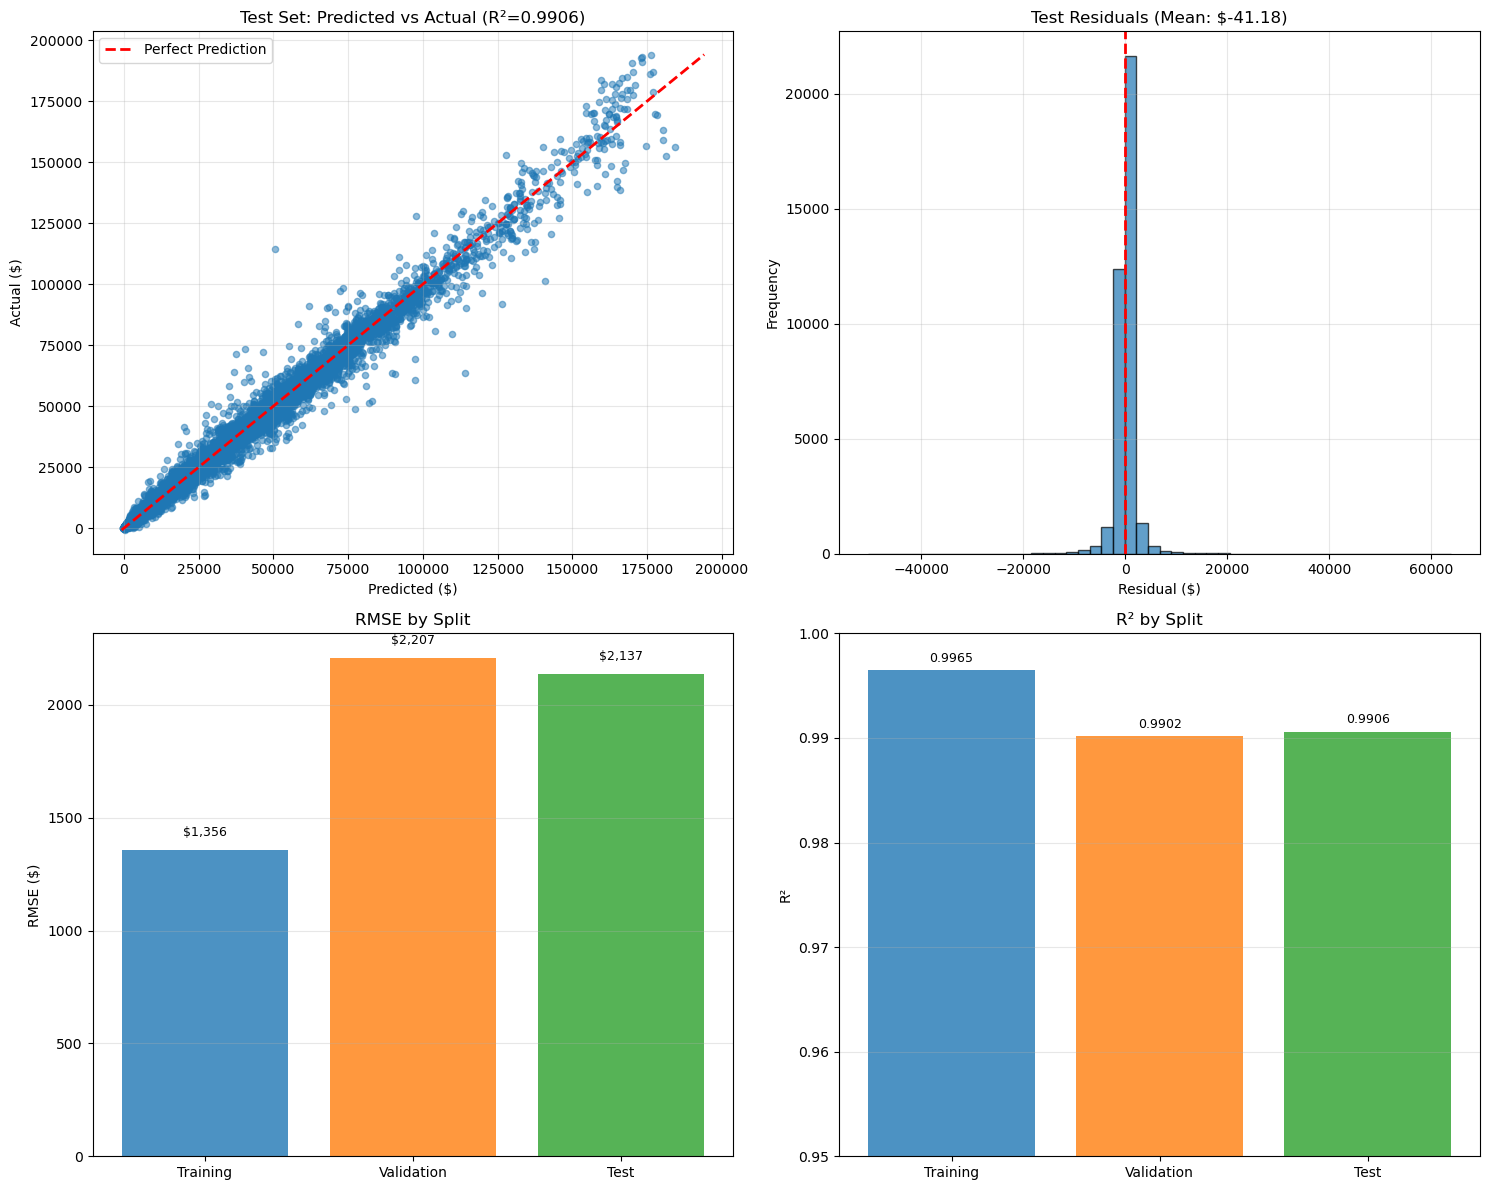

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Predicted vs Actual
axes[0, 0].scatter(test_pred_final, y_test_final, alpha=0.5, s=20)
axes[0, 0].plot([y_test_final.min(), y_test_final.max()],
                [y_test_final.min(), y_test_final.max()], "r--", lw=2, label="Perfect Prediction")
axes[0, 0].set_xlabel("Predicted ($)")
axes[0, 0].set_ylabel("Actual ($)")
axes[0, 0].set_title(f"Test Set: Predicted vs Actual (R²={test_metrics['R2']:.4f})")
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Residuals distribution
test_residuals = y_test_final.values - test_pred_final
axes[0, 1].hist(test_residuals, bins=50, edgecolor="black", alpha=0.7)
axes[0, 1].axvline(x=0, color="red", linestyle="--", linewidth=2)
axes[0, 1].set_xlabel("Residual ($)")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title(f"Test Residuals (Mean: ${test_residuals.mean():.2f})")
axes[0, 1].grid(True, alpha=0.3)

# RMSE comparison
sets       = ["Training", "Validation", "Test"]
rmse_vals  = [train_metrics["RMSE"], val_metrics["RMSE"], test_metrics["RMSE"]]
r2_vals    = [train_metrics["R2"],   val_metrics["R2"],   test_metrics["R2"]]
x_pos      = np.arange(len(sets))
colors     = ["#1f77b4", "#ff7f0e", "#2ca02c"]

bars = axes[1, 0].bar(x_pos, rmse_vals, color=colors, alpha=0.8)
axes[1, 0].set_xticks(x_pos); axes[1, 0].set_xticklabels(sets)
axes[1, 0].set_ylabel("RMSE ($)"); axes[1, 0].set_title("RMSE by Split")
axes[1, 0].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, rmse_vals):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                    f"${val:,.0f}", ha="center", va="bottom", fontsize=9)

bars = axes[1, 1].bar(x_pos, r2_vals, color=colors, alpha=0.8)
axes[1, 1].set_xticks(x_pos); axes[1, 1].set_xticklabels(sets)
axes[1, 1].set_ylabel("R²"); axes[1, 1].set_title("R² by Split")
axes[1, 1].set_ylim([0.95, 1.0])
axes[1, 1].grid(True, alpha=0.3, axis="y")
for bar, val in zip(bars, r2_vals):
    axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                    f"{val:.4f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

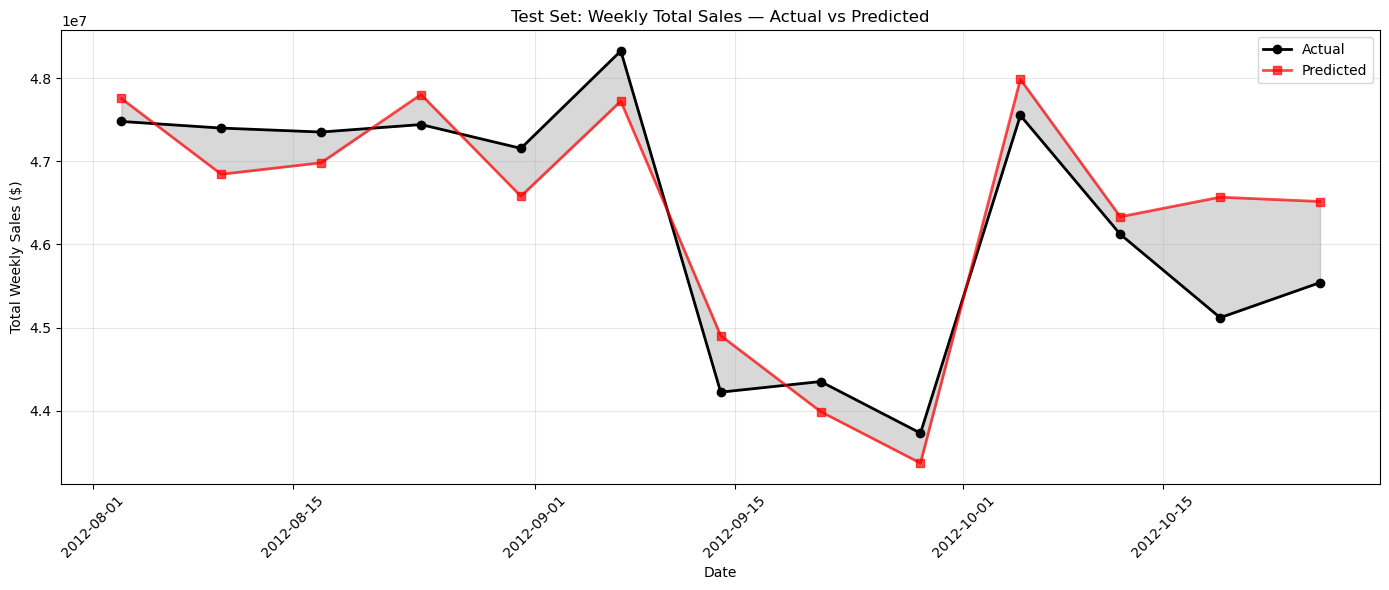

In [35]:
# Weekly aggregated predictions on test set
test_with_pred = test_data.copy()
test_with_pred["Predicted_Sales"] = test_pred_final

weekly_cmp = test_with_pred.groupby("Date").agg(
    {"Weekly_Sales": "sum", "Predicted_Sales": "sum"}
).reset_index()

plt.figure(figsize=(14, 6))
plt.plot(weekly_cmp["Date"], weekly_cmp["Weekly_Sales"],   label="Actual",    linewidth=2, color="black",  marker="o")
plt.plot(weekly_cmp["Date"], weekly_cmp["Predicted_Sales"], label="Predicted", linewidth=2, color="red",    marker="s", alpha=0.7)
plt.fill_between(weekly_cmp["Date"], weekly_cmp["Weekly_Sales"], weekly_cmp["Predicted_Sales"],
                 alpha=0.3, color="gray")
plt.title("Test Set: Weekly Total Sales — Actual vs Predicted")
plt.xlabel("Date"); plt.ylabel("Total Weekly Sales ($)")
plt.legend(); plt.grid(True, alpha=0.3); plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Save Models

In [37]:
import pickle

with open("xgboost_final_validated.pkl", "wb") as f:
    pickle.dump(final_model, f)

with open("prophet_model.pkl", "wb") as f:
    pickle.dump(prophet_model, f)

with open("final_model_metrics.pkl", "wb") as f:
    pickle.dump({"train": train_metrics, "validation": val_metrics, "test": test_metrics,
                 "best_params": best_params.to_dict()}, f)

print("Saved: xgboost_final_validated.pkl")
print("Saved: prophet_model.pkl")
print("Saved: final_model_metrics.pkl")

Saved: xgboost_final_validated.pkl
Saved: prophet_model.pkl
Saved: final_model_metrics.pkl


In [65]:
print("=" * 65)
print("      WALMART SALES FORECASTING — RESULTS SUMMARY")
print("=" * 65)

# Model Comparison
print()
print("  MODEL COMPARISON (Validation Set)")
print("-" * 65)
print(f"  {'Model':<12} {'RMSE':>13} {'MAE':>13} {'R²':>9}")
print(f"  {'Prophet':<12} ${prophet_val_rmse:>12,.2f} ${prophet_val_mae:>12,.2f} {prophet_val_r2:>9.4f}")
print(f"  {'XGBoost':<12} ${xgb_val_rmse:>12,.2f} ${xgb_val_mae:>12,.2f} {xgb_val_r2:>9.4f}")

improvement = (prophet_val_rmse - xgb_val_rmse) / prophet_val_rmse * 100
print(f"  → XGBoost improved over Prophet by {improvement:.1f}% in RMSE")

# MAPE helper (excludes zero/negative actuals)
def safe_mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true > 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

mape_train = safe_mape(y_train_final, train_pred_final)
mape_val   = safe_mape(y_val_final,   val_pred_final)
mape_test  = safe_mape(y_test_final,  test_pred_final)

# Final model across all splits
print()
print("  FINAL XGBOOST — Train / Validation / Test")
print("-" * 65)
print(f"  {'Split':<12} {'RMSE':>13} {'MAE':>13} {'R²':>9} {'MAPE':>8}")
rows = [
    ("Training",   train_metrics, mape_train),
    ("Validation", val_metrics,   mape_val),
    ("Test",       test_metrics,  mape_test),
]
for name, m, mape in rows:
    print(f"  {name:<12} ${m['RMSE']:>12,.2f} ${m['MAE']:>12,.2f} {m['R2']:>9.4f} {mape:>7.2f}%")

r2_drop      = train_metrics['R2'] - test_metrics['R2']
rmse_gap_pct = (test_metrics['RMSE'] - train_metrics['RMSE']) / train_metrics['RMSE'] * 100
print()
print(f"  → R² drop  (train → test): {r2_drop:.4f}")
print(f"  → RMSE gap (train → test): {rmse_gap_pct:.1f}%")

if r2_drop < 0.05 and rmse_gap_pct < 30:
    verdict = "Excellent — minimal overfitting"
elif r2_drop < 0.10 and rmse_gap_pct < 50:
    verdict = "Good — acceptable generalization"
else:
    verdict = "Moderate — consider additional regularization"
print(f"  → Generalization: {verdict}")

# Best hyperparameters
print()
print("  BEST HYPERPARAMETERS")
print("-" * 65)
print(f"  Learning rate : {best_params['learning_rate']}")
print(f"  Max depth     : {int(best_params['max_depth'])}")
print(f"  N estimators  : 500  |  Subsample: 0.8  |  ColSample: 0.8")

# Key findings
print()
print("  KEY FINDINGS")
print("-" * 65)
print("  1. Strong holiday seasonality — weeks 47-52 drive peak sales")
print("  2. Lag features (1-week and 52-week) are the strongest signals")
print("  3. Store size and type (A/B/C) have significant impact")
print("  4. XGBoost outperforms Prophet at store/dept-level granularity")
print("     Prophet is better suited for aggregate trend visualization")
print(f"  5. Final test R² of {test_metrics['R2']*100:.2f}% confirms strong generalization")

print()
print("=" * 65)

      WALMART SALES FORECASTING — RESULTS SUMMARY

  MODEL COMPARISON (Validation Set)
-----------------------------------------------------------------
  Model                 RMSE           MAE        R²
  Prophet      $1,413,464.58 $1,207,509.84    0.0780
  XGBoost      $    2,157.11 $    1,010.88    0.9904
  → XGBoost improved over Prophet by 99.8% in RMSE

  FINAL XGBOOST — Train / Validation / Test
-----------------------------------------------------------------
  Split                 RMSE           MAE        R²     MAPE
  Training     $    1,355.75 $      798.48    0.9965  197.24%
  Validation   $    2,206.84 $    1,006.62    0.9902  175.38%
  Test         $    2,137.01 $      971.64    0.9906   65.25%

  → R² drop  (train → test): 0.0059
  → RMSE gap (train → test): 57.6%
  → Generalization: Moderate — consider additional regularization

  BEST HYPERPARAMETERS
-----------------------------------------------------------------
  Learning rate : 0.07
  Max depth     : 7
  N est